# Project Data Mining: Olist Review Prediction

**Goal:** Build a binary classification model to predict whether an Olist order will receive a Positive or Negative review after delivery.

**Target definition:**
- `0` = Negative review (`review_score` 1, 2, or 3)
- `1` = Positive review (`review_score` 4 or 5)

**Project requirements:**
- Use Jupyter Notebook.
- Use at least 4 models and compare results.
- Explain selected techniques and model behavior.
- Prepare slides for presentation.
- Add contribution details at the end of the notebook.

## 1. Import Libraries

In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)

## 2. Load Data

In [2]:
DATA_DIR = Path("data")

reviews = pd.read_csv(DATA_DIR / "olist_order_reviews_dataset.csv")
orders = pd.read_csv(DATA_DIR / "olist_orders_dataset.csv")
items = pd.read_csv(DATA_DIR / "olist_order_items_dataset.csv")
payments = pd.read_csv(DATA_DIR / "olist_order_payments_dataset.csv")
products = pd.read_csv(DATA_DIR / "olist_products_dataset.csv")
customers = pd.read_csv(DATA_DIR / "olist_customers_dataset.csv")

datasets = {
    "reviews": reviews,
    "orders": orders,
    "items": items,
    "payments": payments,
    "products": products,
    "customers": customers,
}

for name, df in datasets.items():
    print(f"{name}: {df.shape}")

reviews: (99224, 7)
orders: (99441, 8)
items: (112650, 7)
payments: (103886, 5)
products: (32951, 9)
customers: (99441, 5)


## 3. Data Understanding

In [3]:
for name, df in datasets.items():
    print("=" * 80)
    print(name)
    display(df.head())
    display(df.isna().mean().sort_values(ascending=False).head(10))   #  kiểm tra 10 cột có tỷ lệ giá trị bị thiếu cao nhất trong DataFrame df

reviews


,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


review_comment_title       0.883415
review_comment_message     0.587025
review_id                  0.000000
review_score               0.000000
order_id                   0.000000
review_creation_date       0.000000
review_answer_timestamp    0.000000
dtype: float64

orders


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


...

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


product_category_name         0.018512
product_description_lenght    0.018512
product_name_lenght           0.018512
product_photos_qty            0.018512
product_weight_g              0.000061
product_height_cm             0.000061
product_length_cm             0.000061
product_width_cm              0.000061
product_id                    0.000000
dtype: float64

customers


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


customer_id                 0.0
customer_unique_id          0.0
customer_zip_code_prefix    0.0
customer_city               0.0
customer_state              0.0
dtype: float64

## 4. Create Target Variable

In [4]:
reviews_target = reviews[["order_id", "review_score"]].copy()
reviews_target["target"] = np.where(reviews_target["review_score"] >= 4, 1, 0)

reviews_target["target"].value_counts(normalize=True).rename("ratio")
# tỷ lệ phần trăm của từng class trong cột target.

# là khoảng 78.93% đơn hàng có đánh giá tốt, còn 21.07% có đánh giá xấu.

target
1    0.77068
0    0.22932
Name: ratio, dtype: float64

## 5. Feature Engineering

In [5]:
date_cols = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
]

orders_clean = orders.copy()
for col in date_cols:
    orders_clean[col] = pd.to_datetime(orders_clean[col], errors="coerce")
# chuyển các cột ngày từ dạng text sang dạng thời gian thật.
# errors="coerce" nghĩa là nếu giá trị nào không chuyển được thì biến thành NaT

orders_clean = orders_clean[orders_clean["order_status"] == "delivered"].copy()
# Chỉ giữ các đơn hàng có trạng thái delivered. 
# Vì bài toán là: khi đơn hàng đã giao, dự đoán khách có đánh giá xấu không.

orders_clean["delivery_days"] = (
    orders_clean["order_delivered_customer_date"] - orders_clean["order_purchase_timestamp"]
).dt.days # Tính số ngày từ lúc mua hàng đến lúc giao cho khách.
orders_clean["estimated_delivery_days"] = (
    orders_clean["order_estimated_delivery_date"] - orders_clean["order_purchase_timestamp"]
).dt.days # Tính số ngày giao hàng dự kiến.
orders_clean["delay_days"] = (
    orders_clean["order_delivered_customer_date"] - orders_clean["order_estimated_delivery_date"]
).dt.days # Tính số ngày trễ so với ngày dự kiến.
orders_clean["is_late"] = (orders_clean["delay_days"] > 0).astype(int)
# 1: giao trễ
# 0: không giao trễ

items_agg = (
    items.groupby("order_id")
    .agg(
        total_price=("price", "sum"),
        total_freight=("freight_value", "sum"),
        item_count=("order_item_id", "count"),
        product_id=("product_id", "first"),
    )
    .reset_index()
)
# Gom dữ liệu item theo từng đơn hàng

items_agg["freight_ratio"] = items_agg["total_freight"] / items_agg["total_price"].replace(0, np.nan)
# Tạo tỷ lệ phí ship trên giá trị đơn hàng.

payments_agg = (
    payments.groupby("order_id")
    .agg(
        payment_value=("payment_value", "sum"),
        payment_installments=("payment_installments", "max"),
        payment_type=("payment_type", lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan),
    )
    .reset_index()
)
# gom dữ liệu thanh toán theo từng đơn hàng

products_clean = products.copy()
products_clean["product_volume_cm3"] = (
    products_clean["product_length_cm"]
    * products_clean["product_width_cm"]
    * products_clean["product_height_cm"]
)
# volume = length * width * height
# Tính thể tích sản phẩm: Feature này hữu ích vì hàng lớn/cồng kềnh có thể ảnh hưởng đến vận chuyển.

product_cols = [
    "product_id",
    "product_weight_g",
    "product_volume_cm3",
    "product_photos_qty",
    "product_description_lenght",
]

# Chọn các cột sản phẩm cần dùng cho model

model_df = (
    reviews_target.merge(orders_clean, on="order_id", how="inner")
    .merge(items_agg, on="order_id", how="left")
    .merge(payments_agg, on="order_id", how="left")
    .merge(products_clean[product_cols], on="product_id", how="left")
    .merge(customers[["customer_id", "customer_state"]], on="customer_id", how="left")
)
#  Join tất cả bảng lại thành dataset cuối
model_df.shape
# biến nhiều bảng rời rạc của Olist thành một bảng duy nhất model_df, 
# có đầy đủ target và features để train mô hình Machine Learning.

(96361, 27)

## 6. Exploratory Data Analysis

C:\Users\DELL\AppData\Local\Temp\ipykernel_28164\4280487106.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(["Negative", "Positive"])
C:\Users\DELL\AppData\Local\Temp\ipykernel_28164\4280487106.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(["On time", "Late"])


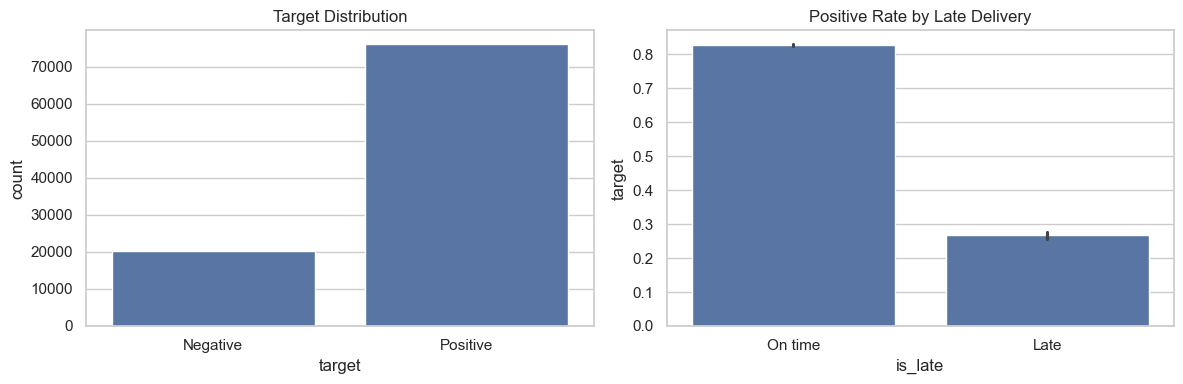

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(data=model_df, x="target", ax=axes[0])
axes[0].set_title("Target Distribution")
axes[0].set_xticklabels(["Negative", "Positive"])

sns.barplot(data=model_df, x="is_late", y="target", ax=axes[1])
axes[1].set_title("Positive Rate by Late Delivery")
axes[1].set_xticklabels(["On time", "Late"])
plt.tight_layout()

In [7]:
numeric_preview = ["delivery_days", "delay_days", "total_price", "total_freight", "freight_ratio"]
model_df.groupby("target")[numeric_preview].median()

,delivery_days,delay_days,total_price,total_freight,freight_ratio
target,,,,,
0,13.0,-9.0,89.97,18.19,0.234928
1,9.0,-13.0,84.90,16.86,0.223033


## 6.1 EDA Findings from the Real Dataset

After joining delivered orders with reviews, items, payments, products, and customers, the modeling dataset contains **96,361 orders** and **27 columns**.

Main observations from the real data:

- Class distribution is imbalanced: **78.93% Positive** and **21.07% Negative**.
- Late delivery is strongly related to bad reviews. Orders delivered on time have about **17.35% Negative** reviews, while late orders have about **73.29% Negative** reviews.
- Negative reviews have a higher median delivery time: **13 days** for Negative vs **9 days** for Positive.
- Negative reviews also have slightly higher median freight cost and freight ratio.
- Payment type alone does not separate outcomes strongly, but voucher orders show the highest Negative ratio among payment types in this dataset.

These findings support using delivery delay, delivery time, freight cost ratio, payment information, product features, and customer state as model inputs.

## 7. Prepare Modeling Dataset

In [8]:
feature_cols = [
    "delivery_days",
    "estimated_delivery_days",
    "delay_days",
    "is_late",
    "total_price",
    "total_freight",
    "item_count",
    "freight_ratio",
    "payment_value",
    "payment_installments",
    "product_weight_g",
    "product_volume_cm3",
    "product_photos_qty",
    "product_description_lenght",
    "payment_type",
    "customer_state",
]

X = model_df[feature_cols].copy()
y = model_df["target"].copy()

numeric_features = X.select_dtypes(include=["int64", "float64", "int32", "float32"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category"]).columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

In [12]:
X

,delivery_days,estimated_delivery_days,delay_days,is_late,total_price,total_freight,item_count,freight_ratio,payment_value,payment_installments,product_weight_g,product_volume_cm3,product_photos_qty,product_description_lenght,payment_type,customer_state
0,6.0,21,-16.0,0,370.00,27.26,2,0.073676,397.26,8.0,1300.0,31500.0,1.0,858.0,credit_card,SP
1,9.0,13,-5.0,0,79.79,8.30,1,0.104023,88.09,1.0,245.0,3724.0,1.0,493.0,credit_card,SP
2,13.0,33,-21.0,0,149.00,45.12,1,0.302819,194.12,1.0,6550.0,8000.0,1.0,1893.0,credit_card,BA
3,10.0,30,-20.0,0,179.99,42.85,1,0.238069,222.84,1.0,7650.0,8000.0,2.0,2188.0,credit_card,SC
4,18.0,26,-9.0,0,1199.00,134.25,1,0.111968,1333.25,10.0,9850.0,183750.0,5.0,562.0,credit_card,SC
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96356,8.0,22,-14.0,0,226.77,61.20,1,0.269877,287.97,8.0,7250.0,62500.0,1.0,623.0,credit_card,GO
96357,4.0,16,-12.0,0,199.99,9.77,1,0.048852,209.76,1.0,2363.0,11799.0,1.0,465.0,credit_card,RJ
96358,3.0,18,-16.0,0,215.97,15.59,1,0.072186,231.56,6.0,4100.0,42920.0,3.0,283.0,credit_card,MG
96359,7.0,23,-16.0,0,50.95,15.46,1,0.303435,66.41,1.0,600.0,1760.0,5.0,998.0,credit_card,MG


In [10]:
X_test

,delivery_days,estimated_delivery_days,delay_days,is_late,total_price,total_freight,item_count,freight_ratio,payment_value,payment_installments,product_weight_g,product_volume_cm3,product_photos_qty,product_description_lenght,payment_type,customer_state
15627,2.0,20,-19.0,0,109.90,15.62,1,0.142129,125.52,2.0,5700.0,60000.0,3.0,704.0,credit_card,PR
22886,4.0,17,-14.0,0,129.00,13.92,1,0.107907,142.92,3.0,3305.0,35100.0,1.0,189.0,credit_card,SP
66219,11.0,22,-12.0,0,21.90,15.10,1,0.689498,37.00,1.0,100.0,528.0,10.0,538.0,credit_card,MG
16966,5.0,19,-15.0,0,89.90,12.13,1,0.134928,102.03,2.0,1383.0,20000.0,1.0,245.0,credit_card,SP
24273,16.0,28,-13.0,0,119.90,17.03,1,0.142035,136.93,2.0,3450.0,13200.0,10.0,863.0,credit_card,RJ
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1720,21.0,27,-6.0,0,19.90,20.52,1,1.031156,40.42,1.0,100.0,3312.0,1.0,287.0,credit_card,MG
71374,16.0,21,-6.0,0,89.90,36.14,1,0.402002,126.04,3.0,7400.0,91125.0,2.0,237.0,credit_card,SP
41179,3.0,20,-17.0,0,99.00,13.71,1,0.138485,112.71,2.0,1650.0,39100.0,1.0,507.0,credit_card,SP
45865,14.0,24,-10.0,0,89.90,15.39,1,0.171190,105.29,1.0,750.0,9900.0,5.0,701.0,boleto,RJ


In [11]:
X_train

,delivery_days,estimated_delivery_days,delay_days,is_late,total_price,total_freight,item_count,freight_ratio,payment_value,payment_installments,product_weight_g,product_volume_cm3,product_photos_qty,product_description_lenght,payment_type,customer_state
73111,18.0,33,-16.0,0,97.99,18.26,1,0.186346,116.25,1.0,1000.0,3640.0,1.0,483.0,voucher,MG
15432,3.0,17,-14.0,0,59.99,9.74,1,0.162360,69.73,1.0,500.0,2400.0,2.0,457.0,credit_card,SP
6950,10.0,23,-13.0,0,59.90,13.00,1,0.217028,72.90,4.0,4100.0,14952.0,4.0,598.0,credit_card,MG
41234,60.0,23,36.0,1,180.16,56.40,4,0.313055,236.56,1.0,150.0,640.0,1.0,2979.0,credit_card,DF
89669,7.0,18,-12.0,0,99.00,7.95,1,0.080303,106.95,1.0,250.0,704.0,2.0,1142.0,boleto,SP
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
46250,16.0,29,-14.0,0,1100.00,40.58,2,0.036891,1140.58,3.0,23200.0,352.0,1.0,1793.0,credit_card,MG
51442,12.0,23,-12.0,0,53.99,15.13,1,0.280237,69.12,6.0,200.0,3328.0,1.0,334.0,credit_card,ES
88646,23.0,24,-1.0,0,79.90,16.32,1,0.204255,96.22,9.0,900.0,3168.0,1.0,192.0,credit_card,MG
65522,16.0,36,-21.0,0,118.58,18.40,1,0.155170,136.98,4.0,800.0,38000.0,2.0,124.0,credit_card,BA


## 8. Train and Compare Models

The project requires at least 4 models. This notebook starts with four baseline models.

In [13]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42),
    "Decision Tree": DecisionTreeClassifier(class_weight="balanced", random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
}

results = []
trained_models = {}

for name, model in models.items():
    clf = Pipeline(steps=[("preprocessor", preprocessor), ("model", model)])
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    y_proba = clf.predict_proba(X_test)[:, 1] if hasattr(clf.named_steps["model"], "predict_proba") else y_pred

    results.append(
        {
            "model": name,
            "accuracy": accuracy_score(y_test, y_pred),
            "positive_precision": precision_score(y_test, y_pred, pos_label=1, zero_division=0),
            "positive_recall": recall_score(y_test, y_pred, pos_label=1, zero_division=0),
            "positive_f1": f1_score(y_test, y_pred, pos_label=1, zero_division=0),
            "negative_precision": precision_score(y_test, y_pred, pos_label=0, zero_division=0),
            "negative_recall": recall_score(y_test, y_pred, pos_label=0, zero_division=0),
            "negative_f1": f1_score(y_test, y_pred, pos_label=0, zero_division=0),
            "roc_auc": roc_auc_score(y_test, y_proba),
        }
    )
    trained_models[name] = clf

results_df = pd.DataFrame(results)

# For this early-warning business problem, the important class is Negative (bad review risk).
# Therefore, the final model is selected by Negative F1, with Negative Recall used as a key supporting metric.
results_by_warning_goal = results_df.sort_values("negative_f1", ascending=False)
results_by_accuracy = results_df.sort_values("accuracy", ascending=False)

display(results_by_warning_goal)


,model,accuracy,positive_precision,positive_recall,positive_f1,negative_precision,negative_recall,negative_f1,roc_auc
0,Logistic Regression,0.750221,0.856623,0.820919,0.838391,0.419932,0.485475,0.450331,0.700601
2,Random Forest,0.821253,0.826906,0.978305,0.896257,0.741582,0.233136,0.354748,0.700898
3,Gradient Boosting,0.822965,0.824952,0.984616,0.897740,0.790698,0.217627,0.341313,0.708570
1,Decision Tree,0.713330,0.823903,0.809874,0.816829,0.330710,0.351797,0.340928,0.580892


## 9. Evaluate the Best Model

Best model for early warning: Logistic Regression
Selection criterion: highest Negative F1, because Negative means risk of bad review.
              precision    recall  f1-score   support

    Negative       0.42      0.49      0.45      4062
    Positive       0.86      0.82      0.84     15211

    accuracy                           0.75     19273
   macro avg       0.64      0.65      0.64     19273
weighted avg       0.76      0.75      0.76     19273



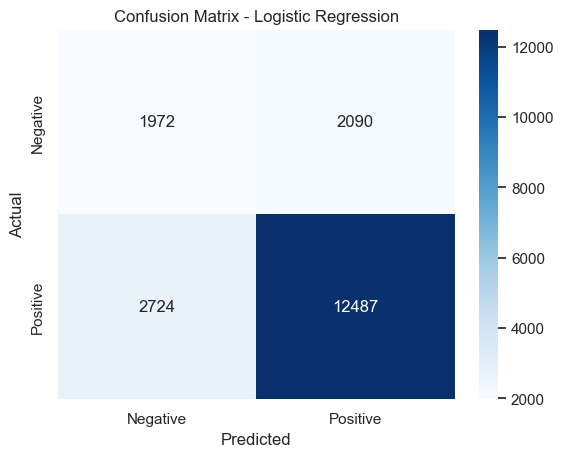

In [ ]:
best_model_name = results_by_warning_goal.iloc[0]["model"]
best_model = trained_models[best_model_name]

y_pred = best_model.predict(X_test)
print("Best model for early warning:", best_model_name)
print("Selection criterion: highest Negative F1, because Negative means risk of bad review.")
print(classification_report(y_test, y_pred, target_names=["Negative", "Positive"]))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Negative", "Positive"], yticklabels=["Negative", "Positive"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix - {best_model_name}");


## 10. Conclusion

The notebook was run successfully on the real Olist datasets from the `data/` folder. After filtering delivered orders and joining the required tables, the final modeling dataset contains **96,361 records**.

### Best model

Using the normal accuracy-oriented view, **Gradient Boosting** has the highest accuracy (**0.823**) and Positive F1 (**0.898**). However, the business goal is an early-warning system for customers likely to leave a bad review, so the more important class is **Negative**.

Using **Negative F1** as the final selection criterion, the best model is **Logistic Regression**:

| Model | Accuracy | Negative Precision | Negative Recall | Negative F1 | ROC-AUC |
|---|---:|---:|---:|---:|---:|
| Logistic Regression | 0.750 | 0.420 | 0.485 | 0.450 | 0.701 |
| Random Forest | 0.821 | 0.742 | 0.233 | 0.355 | 0.701 |
| Gradient Boosting | 0.823 | 0.791 | 0.218 | 0.341 | 0.709 |
| Decision Tree | 0.713 | 0.331 | 0.352 | 0.341 | 0.581 |

### Interpretation

- **Gradient Boosting** and **Random Forest** are better at predicting the majority Positive class, so they achieve higher accuracy.
- **Logistic Regression** detects more Negative cases, with the highest Negative Recall and Negative F1 among the four models.
- For a customer-care warning system, missing a truly unhappy customer is costly. Therefore, **Logistic Regression is the recommended baseline model** for this project objective.
- Delivery-related features are important signals: late delivery and longer delivery time are clearly associated with Negative reviews.

### Suggested next improvements

- Tune the classification threshold to increase Negative Recall.
- Try stronger imbalance-handling methods such as SMOTE or undersampling.
- Add more engineered features, such as seller location distance, category-level aggregates, and historical seller performance.
- Tune hyperparameters for Random Forest and Gradient Boosting to improve Negative-class detection.

## 11. Member Contributions

| Member | Role | Main tasks | Contribution |
|---|---|---|---|
| Member 1 | Data Lead / Data Engineer | Data loading, cleaning, joining, target creation, feature engineering | 33% |
| Member 2 | Modeling Lead / ML Engineer | Preprocessing pipeline, training at least 4 models, evaluation, model selection | 34% |
| Member 3 | Reporting Lead / Analyst & Presenter | EDA visualization, notebook editing, slide preparation, final packaging | 33% |